In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)



Dataset extracted to: /content/dataset


In [4]:
dataset_path = "/content/dataset/Dataset"


In [5]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


In [6]:
img_size = 224
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 80000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [7]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [8]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
output = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)


In [9]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [10]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/resnet50_fake_real_best.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[checkpoint, earlystop]
)


Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6759 - loss: 0.6036
Epoch 1: val_accuracy improved from -inf to 0.74385, saving model to /content/drive/MyDrive/resnet50_fake_real_best.h5


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 282s 107ms/step - accuracy: 0.6759 - loss: 0.6036 - val_accuracy: 0.7438 - val_loss: 0.5184
Epoch 2/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.7484 - loss: 0.5160
Epoch 2: val_accuracy improved from 0.74385 to 0.77130, saving model to /content/drive/MyDrive/resnet50_fake_real_best.h5


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 267s 107ms/step - accuracy: 0.7484 - loss: 0.5160 - val_accuracy: 0.7713 - val_loss: 0.4788
Epoch 3/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.7701 - loss: 0.4835
Epoch 3: val_accuracy improved from 0.77130 to 0.79500, saving model to /content/drive/MyDrive/resnet50_fake_real_best.h5


...

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 266s 106ms/step - accuracy: 0.8117 - loss: 0.4128 - val_accuracy: 0.8202 - val_loss: 0.3982
Epoch 8/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8138 - loss: 0.4098
Epoch 8: val_accuracy did not improve from 0.82015
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 262s 105ms/step - accuracy: 0.8138 - loss: 0.4098 - val_accuracy: 0.8146 - val_loss: 0.3993
Epoch 9/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8180 - loss: 0.4024
Epoch 9: val_accuracy improved from 0.82015 to 0.82480, saving model to /content/drive/MyDrive/resnet50_fake_real_best.h5


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 265s 106ms/step - accuracy: 0.8180 - loss: 0.4024 - val_accuracy: 0.8248 - val_loss: 0.3867
Epoch 10/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8194 - loss: 0.3989
Epoch 10: val_accuracy did not improve from 0.82480
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 263s 105ms/step - accuracy: 0.8194 - loss: 0.3989 - val_accuracy: 0.8092 - val_loss: 0.4247
Epoch 11/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8248 - loss: 0.3899
Epoch 11: val_accuracy improved from 0.82480 to 0.82490, saving model to /content/drive/MyDrive/resnet50_fake_real_best.h5


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 266s 106ms/step - accuracy: 0.8248 - loss: 0.3899 - val_accuracy: 0.8249 - val_loss: 0.3837
Epoch 12/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8261 - loss: 0.3871
Epoch 12: val_accuracy did not improve from 0.82490
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 318s 105ms/step - accuracy: 0.8261 - loss: 0.3871 - val_accuracy: 0.8202 - val_loss: 0.3882
Epoch 13/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8310 - loss: 0.3820
Epoch 13: val_accuracy improved from 0.82490 to 0.84185, saving model to /content/drive/MyDrive/resnet50_fake_real_best.h5


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 266s 107ms/step - accuracy: 0.8310 - loss: 0.3820 - val_accuracy: 0.8418 - val_loss: 0.3695
Epoch 14/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8288 - loss: 0.3824
Epoch 14: val_accuracy improved from 0.84185 to 0.84300, saving model to /content/drive/MyDrive/resnet50_fake_real_best.h5


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 266s 106ms/step - accuracy: 0.8288 - loss: 0.3824 - val_accuracy: 0.8430 - val_loss: 0.3714
Epoch 15/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8292 - loss: 0.3788
Epoch 15: val_accuracy did not improve from 0.84300
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 293s 117ms/step - accuracy: 0.8292 - loss: 0.3788 - val_accuracy: 0.8129 - val_loss: 0.4031


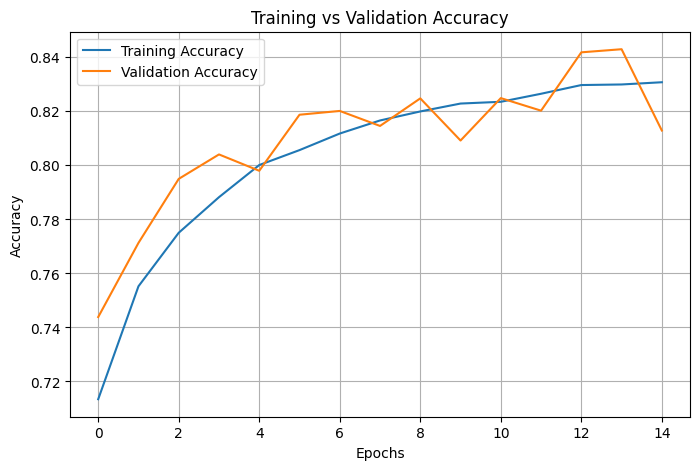

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


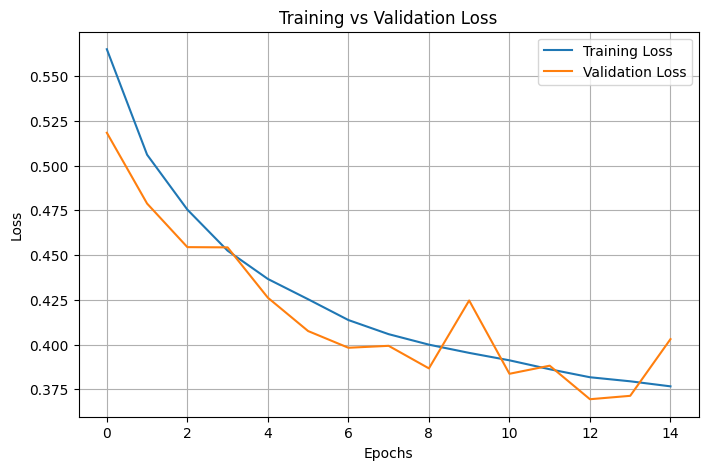

In [12]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()
